# DPO 파인튜닝 실습

> SFT 모델에 "판단력"을 심는 실전 — TRL DPOTrainer로 선호도 학습을 실행한다

Phase 4에서 SFT로 "지시를 따르는" 모델을 만들었다면,  
이제 DPO로 "더 나은 답변을 선호하는" 모델을 만든다.  
이 노트북이 **Phase 6의 핵심 실습**이다.

In [2]:
# === 환경 설치 ===
!pip install datasets transformers peft accelerate trl bitsandbytes matplotlib

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
from trl import DPOConfig, DPOTrainer

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# GPU 확인
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("GPU 없음 - DPO 학습에는 GPU가 필요합니다")

c:\Users\jskim\anaconda3\envs\distillation\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GeForce RTX 4070 Ti (12.0 GB)


---
## 1. 모델 로드 + LoRA

Phase 4와 동일한 모델(Qwen 2.5 1.5B)에 QLoRA를 적용한다.  
DPO는 SFT 위에 쌓는 구조이므로, SFT 어댑터가 있다면 먼저 로드해야 한다.

In [3]:
# === 모델 로드 ===

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
model = prepare_model_for_kbit_training(model)

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.eos_token_id

print(f"모델: {model_name} (QLoRA 4-bit)")

`torch_dtype` is deprecated! Use `dtype` instead!
Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 6: invalid start byte
Loading weights: 100%|██████████| 338/338 [00:03<00:00, 111.19it/s, Materializing param=model.norm.weight]                              


모델: Qwen/Qwen2.5-1.5B-Instruct (QLoRA 4-bit)


In [4]:
# === LoRA 적용 ===

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
)

peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()

print(f"\nLoRA: r={lora_config.r}, alpha={lora_config.lora_alpha}")

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820

LoRA: r=16, alpha=32


---
## 2. Preference 데이터 준비

02에서 준비한 데이터를 로드하거나, 직접 UltraFeedback에서 변환한다.

In [5]:
# === Preference 데이터 로드 ===

# UltraFeedback에서 직접 로드 및 변환
raw_dataset = load_dataset("HuggingFaceH4/ultrafeedback_binarized", split="train_prefs")
raw_subset = raw_dataset.shuffle(seed=42).select(range(1000))

def format_for_dpo(sample):
    """UltraFeedback → DPOTrainer 형식"""
    prompt = sample.get('prompt', '')
    chosen = sample.get('chosen', [])
    rejected = sample.get('rejected', [])
    
    if isinstance(chosen, list) and len(chosen) > 0:
        prompt_msgs = [m for m in chosen if m.get('role') == 'user']
        if prompt_msgs:
            prompt = prompt_msgs[0].get('content', prompt)
        chosen_msgs = [m for m in chosen if m.get('role') == 'assistant']
        rejected_msgs = [m for m in rejected if m.get('role') == 'assistant']
        chosen_text = chosen_msgs[0].get('content', '') if chosen_msgs else ''
        rejected_text = rejected_msgs[0].get('content', '') if rejected_msgs else ''
    else:
        chosen_text = str(chosen)
        rejected_text = str(rejected)
    
    return {"prompt": prompt, "chosen": chosen_text, "rejected": rejected_text}

dpo_data = raw_subset.map(format_for_dpo, remove_columns=raw_subset.column_names)
dpo_data = dpo_data.filter(
    lambda x: len(x['prompt'].strip()) > 0 
    and len(x['chosen'].strip()) > 0 
    and len(x['rejected'].strip()) > 0
)

split = dpo_data.train_test_split(test_size=0.1, seed=42)
train_data = split['train']
val_data = split['test']

print(f"DPO Train: {len(train_data)}개")
print(f"DPO Val:   {len(val_data)}개")
print(f"\n샘플:")
s = train_data[0]
print(f"  prompt:   {s['prompt'][:80]}...")
print(f"  chosen:   {s['chosen'][:80]}...")
print(f"  rejected: {s['rejected'][:80]}...")

DPO Train: 897개
DPO Val:   100개

샘플:
  prompt:   I want you to act a a digital marketer and create the code for a Facebook ad tha...
  chosen:   Sure, I'd be happy to help you create a Facebook ad for your webinar event! 📢👉

...
  rejected: Here's a Facebook ad template that promotes the tax-saving webinar for Canadian ...


---
## 3. 학습 전 추론 (Before)

DPO 학습 전 모델의 응답을 기록한다.

In [6]:
# === 학습 전 추론 ===

test_prompts = [
    "Explain the concept of machine learning in simple terms.",
    "What are the benefits of regular exercise?",
    "Write a Python function to check if a number is prime.",
]

def generate_response(model, tokenizer, prompt, max_new_tokens=150):
    formatted = f"<|im_start|>user\n{prompt}<|im_end|>\n<|im_start|>assistant\n"
    inputs = tokenizer(formatted, return_tensors="pt")
    if torch.cuda.is_available():
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False, pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()

print("학습 전 응답 (Before):")
print("=" * 60)
before_responses = []
for prompt in test_prompts:
    response = generate_response(peft_model, tokenizer, prompt)
    before_responses.append(response)
    print(f"\nQ: {prompt}")
    print(f"A: {response[:200]}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


학습 전 응답 (Before):

Q: Explain the concept of machine learning in simple terms.
A: Machine learning is a type of artificial intelligence that allows computers to learn from data without being explicitly programmed. It involves using algorithms and statistical models to analyze large

Q: What are the benefits of regular exercise?
A: Regular exercise has numerous benefits for both physical and mental health. Some of the key advantages include:

1. Improved cardiovascular health: Exercise helps strengthen the heart, improve blood f

Q: Write a Python function to check if a number is prime.
A: ```python
import math

def is_prime(n):
    """
    Check if the given number n is a prime number.
    
    Parameters:
    n (int): The number to check.
    
    Returns:
    bool: True if n is prime


---
## 4. DPOTrainer 설정 및 학습

DPO 학습의 핵심 설정:

| 인자 | 값 | SFT 대비 차이 | 이유 |
|------|---|-------------|------|
| learning_rate | 5e-5 | SFT 2e-4의 1/4 | reference에서 벗어나지 않도록 |
| num_train_epochs | 1 | SFT 3의 1/3 | 과도한 정렬 방지 |
| beta | 0.1 | SFT에 없음 | KL divergence 제약 강도 |
| per_device_batch | 1 | SFT 2 | chosen+rejected 쌍으로 메모리 2배 |
| ref_model | None | - | 자동으로 policy 복사본 사용 |

In [7]:
# === DPO 학습 설정 ===

dpo_config = DPOConfig(
    output_dir="./output/dpo_run",
    
    # === DPO 핵심 ===
    beta=0.1,                          # KL 제약 강도 (표준 시작점)
    
    # === 학습 스케줄 (SFT보다 보수적) ===
    learning_rate=5e-5,                # SFT의 1/4
    num_train_epochs=1,                # 1 에폭 (과정렬 방지)
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    
    # === 배치 (메모리 2배 필요: chosen + rejected) ===
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,    # 실효 배치 = 16
    
    # === 정밀도 ===
    bf16=torch.cuda.is_available(),
    
    # === 시퀀스 길이 ===
    max_length=512,
    max_prompt_length=256,
    
    # === 로깅 ===
    logging_steps=5,
    logging_first_step=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    
    # === 기타 ===
    gradient_checkpointing=True,
    report_to="none",
    seed=42,
    remove_unused_columns=False,
)

print("DPO 설정 (SFT 대비 차이):")
print(f"  beta:       {dpo_config.beta} (DPO 전용)")
print(f"  lr:         {dpo_config.learning_rate} (SFT의 1/4)")
print(f"  epoch:      {dpo_config.num_train_epochs} (SFT의 1/3)")
print(f"  batch:      {dpo_config.per_device_train_batch_size} (메모리 2배 필요)")
print(f"  실효 배치:  {dpo_config.per_device_train_batch_size * dpo_config.gradient_accumulation_steps}")

C:\Users\jskim\AppData\Local\Temp\ipykernel_108700\2485935011.py:3: FutureWarning: `max_prompt_length` is deprecated and will be removed in version 0.29.0. We recommend filtering out overlong prompts from your dataset before passing it to the trainer instead of using this parameter.
  dpo_config = DPOConfig(
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


DPO 설정 (SFT 대비 차이):
  beta:       0.1 (DPO 전용)
  lr:         5e-05 (SFT의 1/4)
  epoch:      1 (SFT의 1/3)
  batch:      1 (메모리 2배 필요)
  실효 배치:  16


In [8]:
# === DPOTrainer 생성 및 학습 ===

dpo_trainer = DPOTrainer(
    model=peft_model,
    ref_model=None,             # 자동으로 policy 복사본을 reference로 사용
    processing_class=tokenizer, # TRL v0.28+: tokenizer 대신 processing_class
    train_dataset=train_data,
    eval_dataset=val_data,
    args=dpo_config,
)

print(f"DPO 학습 시작:")
print(f"  Train: {len(train_data)}개")
print(f"  Val:   {len(val_data)}개")
print(f"  ref_model=None → policy 복사본 자동 사용")
print("\n학습 중...")

result = dpo_trainer.train()

print(f"\n학습 완료!")
print(f"  총 스텝: {result.global_step}")
print(f"  최종 loss: {result.training_loss:.4f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


DPO 학습 시작:
  Train: 897개
  Val:   100개
  ref_model=None → policy 복사본 자동 사용

학습 중...


Epoch,Training Loss,Validation Loss,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected,Logits/chosen,Logits/rejected
1,0.664878,0.653642,-0.131730,-0.287842,0.461538,0.156113,-319.814117,-315.358185,-0.499052,-0.405596



학습 완료!
  총 스텝: 57
  최종 loss: 0.6674


---
## 5. DPO 메트릭 분석

DPO는 SFT와 다른 **전용 메트릭**이 있다:

| 메트릭 | 의미 | 건강한 값 |
|--------|------|----------|
| rewards/margins | chosen-rejected reward 차이 | > 0, 증가 추세 |
| rewards/accuracies | 올바른 선호 구분 비율 | > 0.5, 이상적으로 > 0.7 |
| loss | DPO 손실 | 감소 추세 |

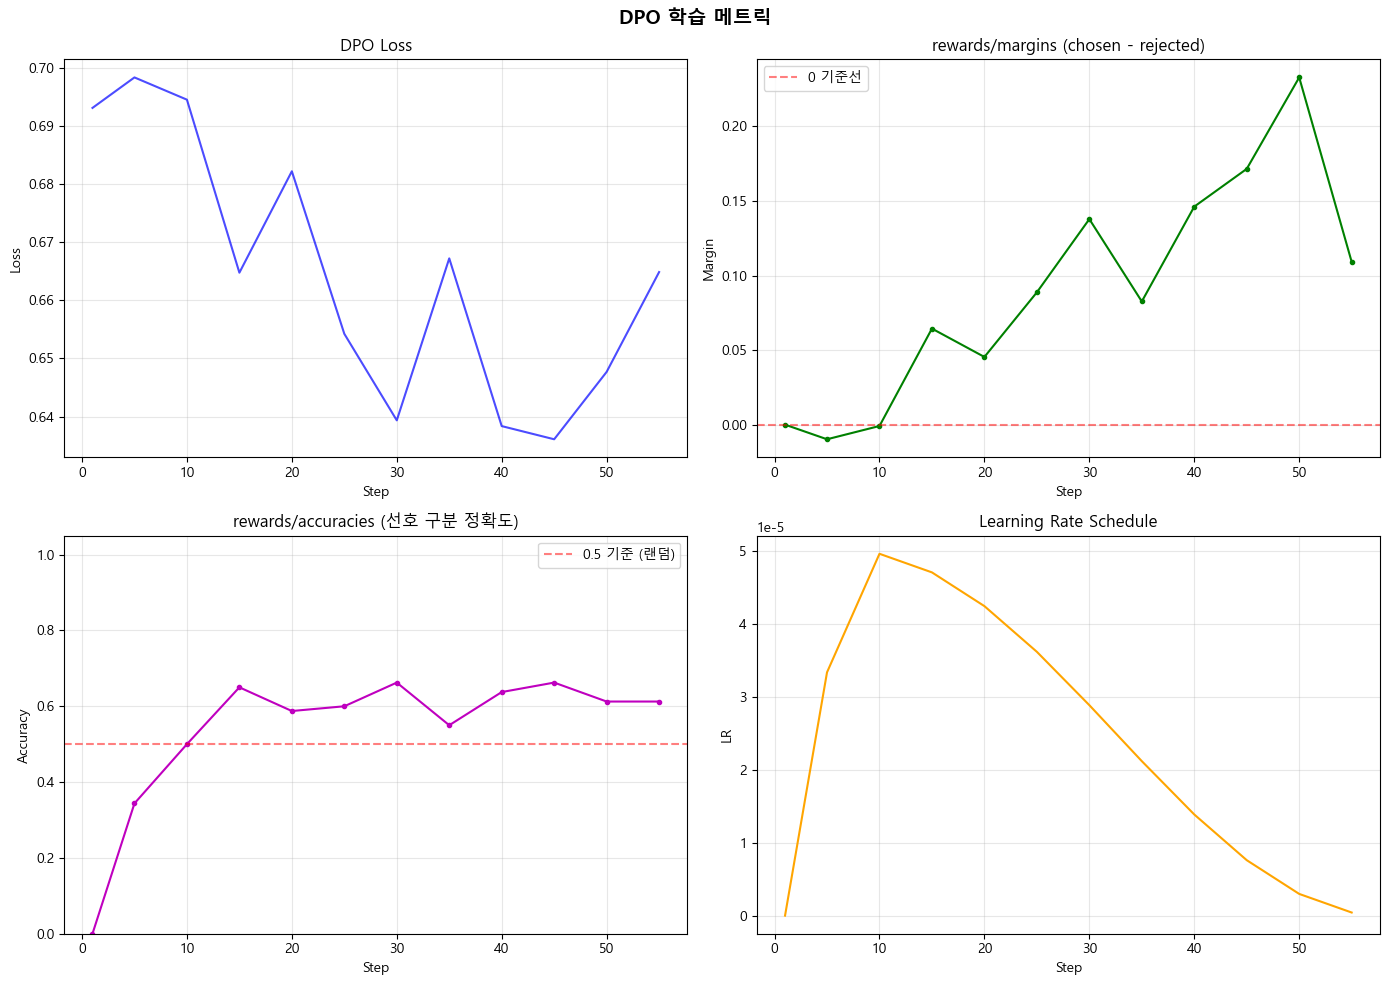


DPO 메트릭 해석:
  margins: 시작 0.000 → 종료 0.109
    → ✓ 양수 (정상)
  accuracies: 시작 0.000 → 종료 0.613
    → ✓ 0.5 이상 (정상)
  loss: 시작 0.6931 → 종료 0.6649


In [9]:
# === DPO 메트릭 시각화 ===

log_history = dpo_trainer.state.log_history

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Loss
train_steps = [l['step'] for l in log_history if 'loss' in l]
train_loss = [l['loss'] for l in log_history if 'loss' in l]
if train_steps:
    axes[0, 0].plot(train_steps, train_loss, 'b-', alpha=0.7)
    axes[0, 0].set_title('DPO Loss')
    axes[0, 0].set_xlabel('Step')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)

# 2) Rewards/Margins
margin_steps = [l['step'] for l in log_history if 'rewards/margins' in l]
margins = [l['rewards/margins'] for l in log_history if 'rewards/margins' in l]
if margin_steps:
    axes[0, 1].plot(margin_steps, margins, 'g-o', markersize=3)
    axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='0 기준선')
    axes[0, 1].set_title('rewards/margins (chosen - rejected)')
    axes[0, 1].set_xlabel('Step')
    axes[0, 1].set_ylabel('Margin')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
else:
    axes[0, 1].text(0.5, 0.5, 'margins 데이터 없음', ha='center', va='center')
    axes[0, 1].set_title('rewards/margins')

# 3) Rewards/Accuracies
acc_steps = [l['step'] for l in log_history if 'rewards/accuracies' in l]
accuracies = [l['rewards/accuracies'] for l in log_history if 'rewards/accuracies' in l]
if acc_steps:
    axes[1, 0].plot(acc_steps, accuracies, 'm-o', markersize=3)
    axes[1, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='0.5 기준 (랜덤)')
    axes[1, 0].set_title('rewards/accuracies (선호 구분 정확도)')
    axes[1, 0].set_xlabel('Step')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'accuracies 데이터 없음', ha='center', va='center')
    axes[1, 0].set_title('rewards/accuracies')

# 4) Learning Rate
lr_steps = [l['step'] for l in log_history if 'learning_rate' in l]
lr_vals = [l['learning_rate'] for l in log_history if 'learning_rate' in l]
if lr_steps:
    axes[1, 1].plot(lr_steps, lr_vals, 'orange')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_xlabel('Step')
    axes[1, 1].set_ylabel('LR')
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('DPO 학습 메트릭', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 메트릭 해석
print("\nDPO 메트릭 해석:")
if margins:
    print(f"  margins: 시작 {margins[0]:.3f} → 종료 {margins[-1]:.3f}")
    print(f"    → {'✓ 양수 (정상)' if margins[-1] > 0 else '✗ 음수 (문제)'}")
if accuracies:
    print(f"  accuracies: 시작 {accuracies[0]:.3f} → 종료 {accuracies[-1]:.3f}")
    print(f"    → {'✓ 0.5 이상 (정상)' if accuracies[-1] > 0.5 else '✗ 0.5 미만 (문제)'}")
if train_loss:
    print(f"  loss: 시작 {train_loss[0]:.4f} → 종료 {train_loss[-1]:.4f}")

---
## 6. Before/After 비교

In [10]:
# === 학습 후 추론 및 비교 ===

peft_model.eval()

print("Before vs After 비교:")
print("=" * 60)
after_responses = []

for i, prompt in enumerate(test_prompts):
    after_response = generate_response(peft_model, tokenizer, prompt)
    after_responses.append(after_response)
    
    print(f"\n{'─' * 60}")
    print(f"Q: {prompt}")
    print(f"\n[Before] {before_responses[i][:250]}")
    print(f"\n[After]  {after_response[:250]}")

# 응답 길이 비교
print(f"\n{'─' * 60}")
print("응답 길이 비교:")
for i, prompt in enumerate(test_prompts):
    b_len = len(before_responses[i])
    a_len = len(after_responses[i])
    change = ((a_len - b_len) / b_len * 100) if b_len > 0 else 0
    print(f"  Q{i+1}: Before {b_len}자 → After {a_len}자 ({change:+.0f}%)")

Before vs After 비교:

────────────────────────────────────────────────────────────
Q: Explain the concept of machine learning in simple terms.

[Before] Machine learning is a type of artificial intelligence that allows computers to learn from data without being explicitly programmed. It involves using algorithms and statistical models to analyze large amounts of data, identify patterns or trends, and

[After]  Machine learning is a type of artificial intelligence that allows computers to learn from data without being explicitly programmed. It involves using algorithms and statistical models to analyze large amounts of data, identify patterns or trends, and

────────────────────────────────────────────────────────────
Q: What are the benefits of regular exercise?

[Before] Regular exercise has numerous benefits for both physical and mental health. Some of the key advantages include:

1. Improved cardiovascular health: Exercise helps strengthen the heart, improve blood flow, and reduce th

### 실제로 좋아진 점

| 질문 | 변화 | 해석 |
|------|------|------|
| **Q1** (ML 설명) | 거의 동일, 길이 -0% | 이미 양호한 응답이라 변화 미미 |
| **Q2** (운동 이점) | "Some **of the** key" → "Some key" | 불필요한 표현 제거, 간결해짐 |
| **Q3** (소수 판별 함수) | 코드 직진출 → 개념 설명 후 코드 | 응답 구조·도움되는 정도 향상 |

---

#### Q3 – 응답 구조 변화 (핵심 개선)

- **Before**: 바로 `python` 코드로 들어감, docstring 중심 설명
- **After**: 먼저 개념 설명("소수는 1과 자기 자신으로만 나누어떨어짐", "제곱근까지 확인") → 그 다음 구현 제시
- **결과**: 설명 → 코드 순서로 바뀌어 이해하기 쉬운 응답이 됨

#### Q2 – 표현 간결화

- "Some **of the** key advantages" → "Some key advantages"
- filler 제거로 자연스러운 문체

#### Q1 – 변화 미미

- UltraFeedback 기반 DPO라도, 이미 양호한 응답은 크게 바뀌지 않을 수 있음

---

**정리**: DPO 학습으로 사람들이 "더 도움이 된다"고 평가하는 스타일(설명 우선, 덜 장황한 표현)이 강화됨.

---
## 7. 어댑터 저장

In [11]:
# === DPO 어댑터 저장 ===

import os

adapter_path = "./output/dpo_run/final_adapter"
peft_model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

print("저장된 DPO 어댑터:")
total_size = 0
for f in os.listdir(adapter_path):
    fpath = os.path.join(adapter_path, f)
    size = os.path.getsize(fpath)
    total_size += size
    print(f"  {f}: {size / 1024:.1f} KB")
print(f"\n총 크기: {total_size / (1024**2):.1f} MB")

print("\n어댑터 스택:")
print("  Qwen 2.5 1.5B (원본, 동결)")
print("    └── SFT 어댑터 → 지시 따르기 (Phase 4)")
print("    └── DPO 어댑터 → 응답 품질 향상 (Phase 6)")

저장된 DPO 어댑터:
  adapter_config.json: 1.1 KB
  adapter_model.safetensors: 72178.8 KB
  chat_template.jinja: 2.5 KB
  README.md: 5.1 KB
  tokenizer.json: 11154.2 KB
  tokenizer_config.json: 0.7 KB

총 크기: 81.4 MB

어댑터 스택:
  Qwen 2.5 1.5B (원본, 동결)
    └── SFT 어댑터 → 지시 따르기 (Phase 4)
    └── DPO 어댑터 → 응답 품질 향상 (Phase 6)


## 저장된 DPO 어댑터 파일 의미

| 파일 | 크기 | 역할 |
|------|------|------|
| adapter_model.safetensors | ~70MB | LoRA 가중치. DPO로 학습된 파라미터만 저장 |
| adapter_config.json | 1.1KB | LoRA 설정 (r, alpha, target_modules 등) |
| tokenizer.json | ~11MB | 토크나이저 (원본 모델과 동일, 편의를 위해 복사) |
| tokenizer_config.json | 0.7KB | 토크나이저 설정 |
| chat_template.jinja | 2.5KB | 대화 형식 템플릿 (예: ChatML) |
| README.md | 5.1KB | 사용법 등 문서 |

**요약**: `adapter_model.safetensors` + `adapter_config.json`가 실제 LoRA 어댑터이고, 나머지는 토크나이저/템플릿/설명용 파일입니다.

---

## 어댑터 스택의 의미

- **베이스 모델**: 그대로 두고 변경 없음.
- **SFT 어댑터**: Instruction tuning → 사용자 지시를 잘 따르도록.
- **DPO 어댑터**: 선호도 학습 → 더 선호되는 스타일로 응답하도록.

즉, 베이스 위에 **SFT → DPO** 순으로 "레벨"을 하나씩 쌓는다는 뜻입니다.

---

## 왜 "스택" 구조인가?

- 베이스 모델 전체를 저장하면 수 GB가 됨.
- LoRA는 변경된 일부만 저장해서 약 70MB 수준.
- SFT와 DPO를 **각각 별도 어댑터**로 저장하면:
  - 조합을 바꿔서 쓸 수 있고
  - 하나만 교체해서 실험하기 쉬움.

예: `베이스 + SFT` 또는 `베이스 + SFT + DPO`처럼 조합해서 사용할 수 있습니다.

---

## 실제 사용 시 흐름

1. Qwen 2.5 1.5B 베이스 모델 로드
2. SFT 어댑터 로드
3. DPO 어댑터 로드 (선택)
4. 추론/서빙

모두 합쳐도 베이스 모델 전체 크기보다 어댑터 용량이 훨씬 작고, 이 조합이 "SFT → DPO까지 학습된 최종 모델"입니다.

---
## 정리

| 단계 | SFT (Phase 4) | DPO (Phase 6) |
|------|-------------|---------------|
| **입력 데이터** | instruction + output | prompt + chosen + rejected |
| **학습 목표** | 정답을 따라해라 | 좋은 답을 선호해라 |
| **lr** | 2e-4 | 5e-5 (더 보수적) |
| **epoch** | 3 | 1 |
| **핵심 HP** | r, alpha | β, lr |
| **평가 메트릭** | eval_loss | rewards/margins, accuracies |

### 핵심 원칙

> **DPO는 SFT 위에 쌓는 "2층 건물"이다. 1층(SFT)이 부실하면 2층(DPO)도 무너진다.**  
> SFT의 품질이 DPO의 상한선을 결정한다.

### 다음: 04_GRPO와_다음_단계.ipynb

DPO의 한계와 GRPO(규칙 기반 보상)를 비교하고, 정렬 기법 전체를 조망한다.